In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import skew, kurtosis
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

In [3]:
def extract_all_features_robust(img):
    try:
        if img is None or img.size == 0:
            return None
        
        # 1. Standardize Image
        img = cv2.resize(img, (128, 128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        features = []

        # --- 1. FIRST-ORDER STATISTICS (16 features) ---
        for channel in [gray, hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]]:
            flat = channel.flatten().astype(np.float64)
            features.extend([np.mean(flat), np.std(flat), skew(flat), kurtosis(flat)])

        # --- 2. HUE HISTOGRAM (HueHist - 32 features) ---
        hue_hist = cv2.calcHist([hsv], [0], None, [32], [0, 180]).flatten()
        features.extend(hue_hist / (np.sum(hue_hist) + 1e-7))

        # --- 3. SIFT DESCRIPTORS (129 features) ---
        sift = cv2.SIFT_create()
        kp, desc = sift.detectAndCompute(gray, None)
        if desc is not None:
            features.extend(np.mean(desc, axis=0)) # Average descriptor (128)
            features.append(len(kp))               # Keypoint count (1)
        else:
            features.extend([0]*129)

        # --- 4. HOG (Histogram of Oriented Gradients - 1764 features) ---
        hog_feats = hog(gray, orientations=9, pixels_per_cell=(16, 16), 
                        cells_per_block=(2, 2), visualize=False)
        features.extend(hog_feats)

        # --- 5. LBP (Local Binary Pattern - 10 features) ---
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
        features.extend(lbp_hist / (np.sum(lbp_hist) + 1e-7))

        # --- 6. GLCM TEXTURE (5 features) ---
        glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
            features.append(graycoprops(glcm, prop)[0, 0])

        # --- 7. CANNY DENSITY & CONTOUR/BBOX (6 features) ---
        # Robust edge detection
        edges = cv2.Canny(gray, 100, 200)
        canny_density = np.sum(edges > 0) / (edges.size + 1e-7)
        features.append(canny_density)
        
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(c)
            peri = cv2.arcLength(c, True)
            x, y, w, h = cv2.boundingRect(c)
            
            # Prevent Division by Zero & Handle Geometry Errors
            aspect_ratio = w / h if h != 0 else 0
            extent = area / (w * h) if (w * h) != 0 else 0
            circularity = (4 * np.pi * area) / (peri**2 + 1e-7)
            features.extend([area/16384, peri/512, aspect_ratio, extent, circularity])
        else:
            features.extend([0]*5)

        # --- 8. HU MOMENTS (7 features) ---
        hu = cv2.HuMoments(cv2.moments(gray)).flatten()
        # Log transformation to prevent integer overflow/scaling issues
        hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
        features.extend(hu_log)

        return np.array(features, dtype=np.float32)

    except Exception as e:
        print(f"Skipping corrupted data: {e}")
        return None

In [4]:
def augment_image(img):
    # Flip
    if np.random.rand() > 0.5: img = cv2.flip(img, 1)
    # Brightness
    value = np.random.randint(-30, 30)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, value)
    v[v > 255] = 255
    v[v < 0] = 0
    final_hsv = cv2.merge((h, s, v))
    return cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

def load_robust_dataset(base_path):
    X, y = [], []
    # Auto-detect structure: Binary Folders or Mixed
    subdirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    if len(subdirs) >= 2:
        class_map = {subdirs[0]: 0, subdirs[1]: 1}
        print(f"Detected Binary Classes: {class_map}")
    else:
        print("Detected Mixed Folder or Single Class. Check labels manually.")
        return None, None

    for cls, label in class_map.items():
        folder = os.path.join(base_path, cls)
        for file in os.listdir(folder):
            path = os.path.join(folder, file)
            img = cv2.imread(path)
            
            # Robust Error Handling
            if img is None or img.size == 0: continue
            
            # Feature extraction for original
            feats = extract_robust_features(img)
            if feats is not None:
                X.append(feats); y.append(label)
                
                # Augmentation (Double the data)
                aug_img = augment_image(img)
                aug_feats = extract_robust_features(aug_img)
                if aug_feats is not None:
                    X.append(aug_feats); y.append(label)

    return np.array(X), np.array(y)

In [5]:
import matplotlib.pyplot as plt

def visualize_all_processes(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Process visualizations
    edges = cv2.Canny(gray, 100, 200)
    lbp = local_binary_pattern(gray, 8, 1, method='uniform')
    _, hog_v = hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True)
    sift = cv2.SIFT_create(); kp, _ = sift.detectAndCompute(gray, None)
    sift_img = cv2.drawKeypoints(img_rgb, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    plt.figure(figsize=(20, 10))
    # Row 1
    plt.subplot(2, 4, 1); plt.imshow(img_rgb); plt.title("1. Original Image")
    plt.subplot(2, 4, 2); plt.imshow(gray, cmap='gray'); plt.title("2. Grayscale")
    plt.subplot(2, 4, 3); plt.imshow(hsv[:,:,0], cmap='hsv'); plt.title("3. Hue Channel")
    plt.subplot(2, 4, 4); plt.plot(cv2.calcHist([hsv],[0],None,[180],[0,180])); plt.title("4. Hue Histogram")

    # Row 2
    plt.subplot(2, 4, 5); plt.imshow(edges, cmap='gray'); plt.title("5. Canny Density")
    plt.subplot(2, 4, 6); plt.imshow(lbp, cmap='inferno'); plt.title("6. LBP Texture")
    plt.subplot(2, 4, 7); plt.imshow(sift_img); plt.title("7. SIFT Keypoints")
    plt.subplot(2, 4, 8); plt.imshow(hog_v, cmap='jet'); plt.title("8. HOG Structure")
    
    plt.tight_layout(); plt.show()

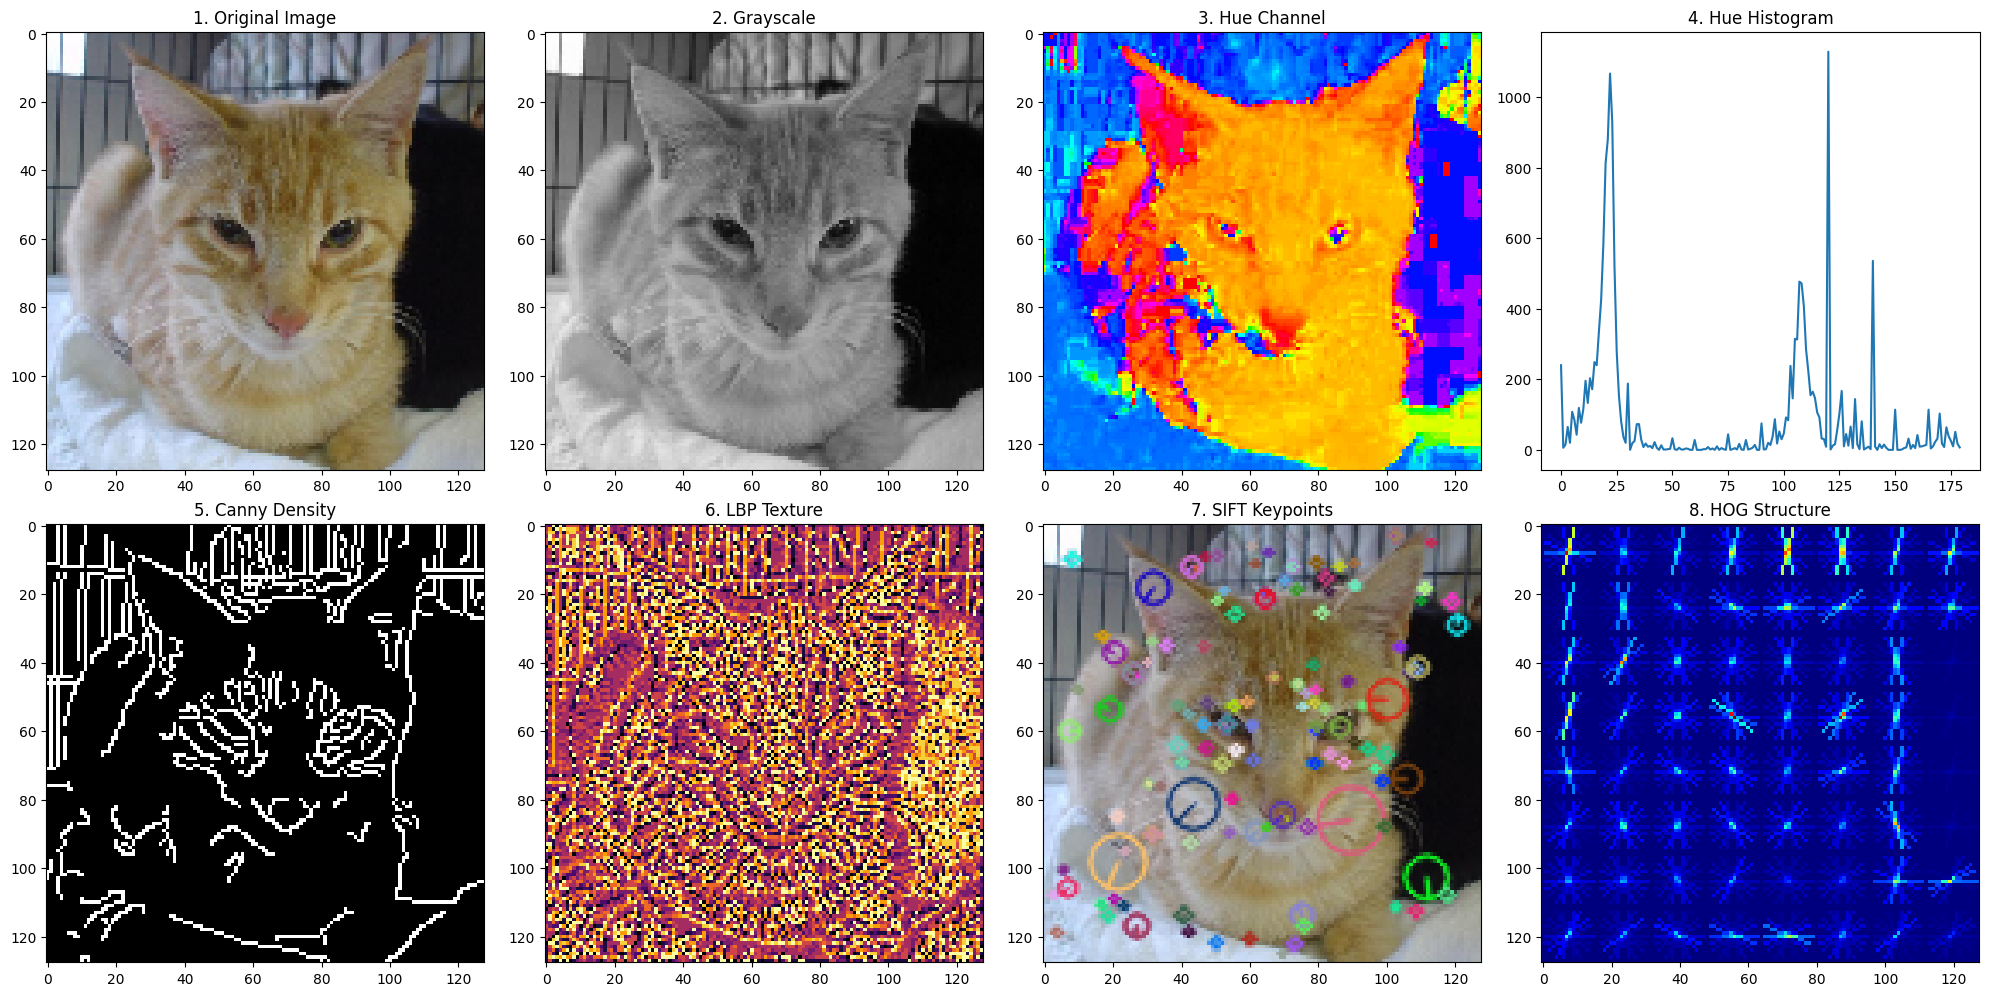

In [6]:

visualize_all_processes("/kaggle/input/competitions/ai-309-e-icv-mse-2/train/train/Cat/25003.jpg")

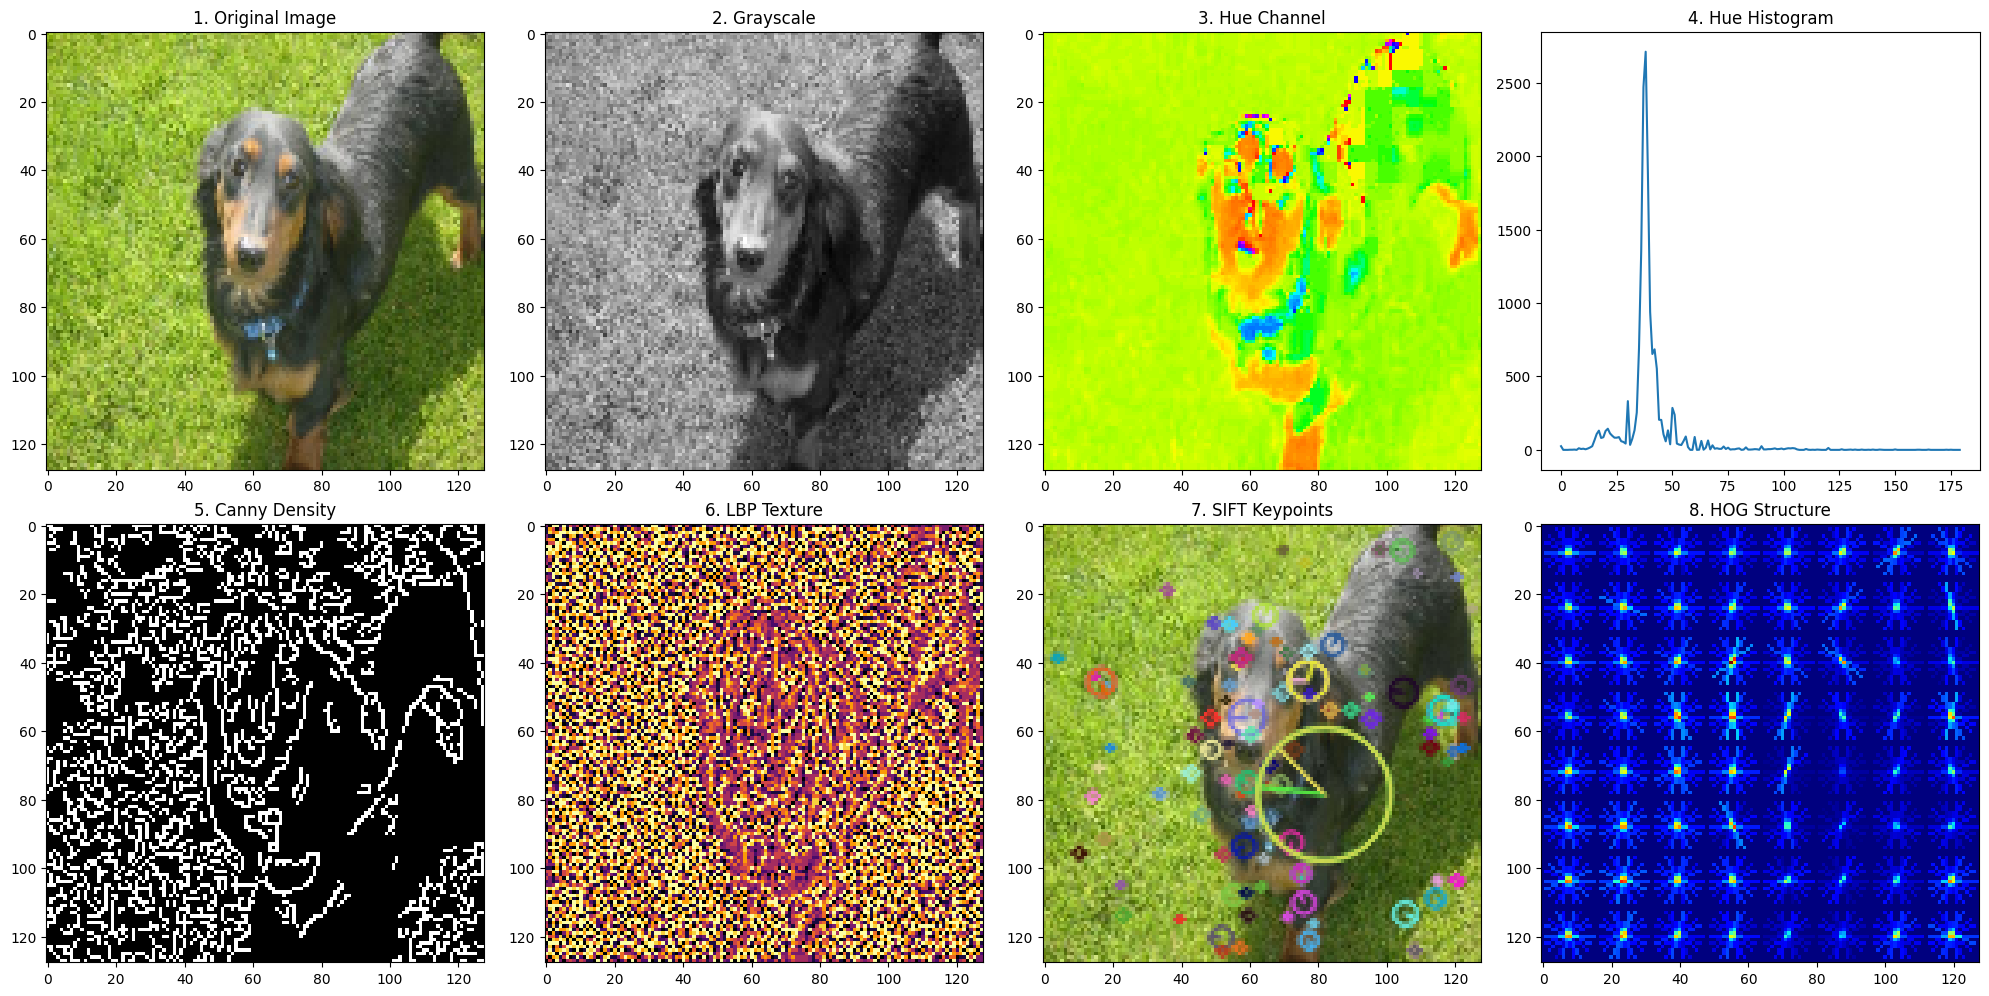

In [7]:

visualize_all_processes("/kaggle/input/competitions/ai-309-e-icv-mse-2/train/train/Dog/31021.jpg")

In [8]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

def prepare_dataset_robust(base_path):
    X_list, y_list = [], []
    subdirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    print(f"Extracting features from: {subdirs}")
    for class_name in subdirs:
        folder = os.path.join(base_path, class_name)
        for file in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, file))
            if img is None: continue
            
            # Original and Augmented (Horizontal Flip)
            for process in [img, cv2.flip(img, 1)]:
                feats = extract_all_features_robust(process)
                if feats is not None:
                    X_list.append(feats)
                    y_list.append(class_name)

    X_array = np.array(X_list)
    y_array = np.array(y_list)

    # --- HANDLING NaN & Inf (THE FIX) ---
    # Replace Infinity with NaN, then replace NaN with Mean
    X_array[np.isinf(X_array)] = np.nan
    imputer = SimpleImputer(strategy='mean')
    X_clean = imputer.fit_transform(X_array)
    
    # Label Encoding
    le = LabelEncoder()
    y_enc = le.fit_transform(y_array)
    
    return X_clean, y_enc, le

In [9]:
# Execute
X_final, y_final, le = prepare_dataset_robust("/kaggle/input/competitions/ai-309-e-icv-mse-2/train/train")

Extracting features from: ['Dog', 'Cat']


Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


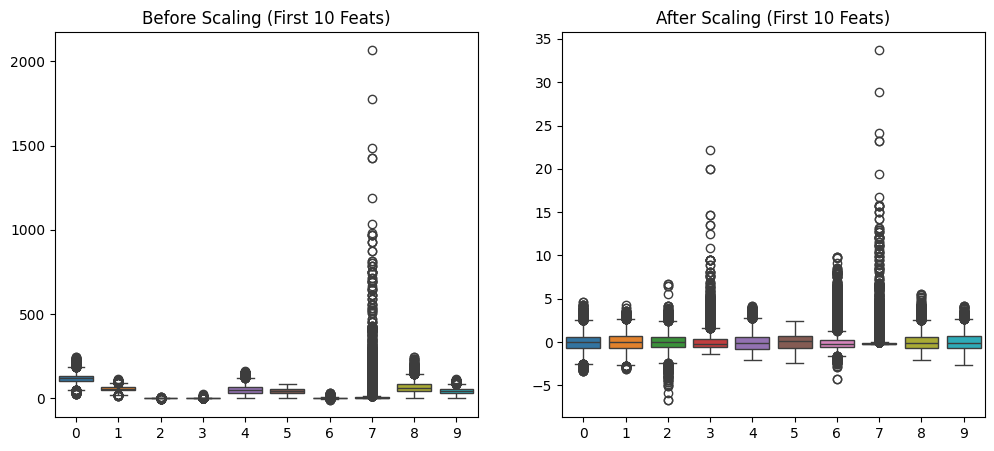

In [10]:
# 1. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y_final, random_state=42
)

# 2. SMOTE (Balancing)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Visualization: Before vs After Scaling
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train_res[:, :10])
plt.title("Before Scaling (First 10 Feats)")
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[:, :10])
plt.title("After Scaling (First 10 Feats)")
plt.show()

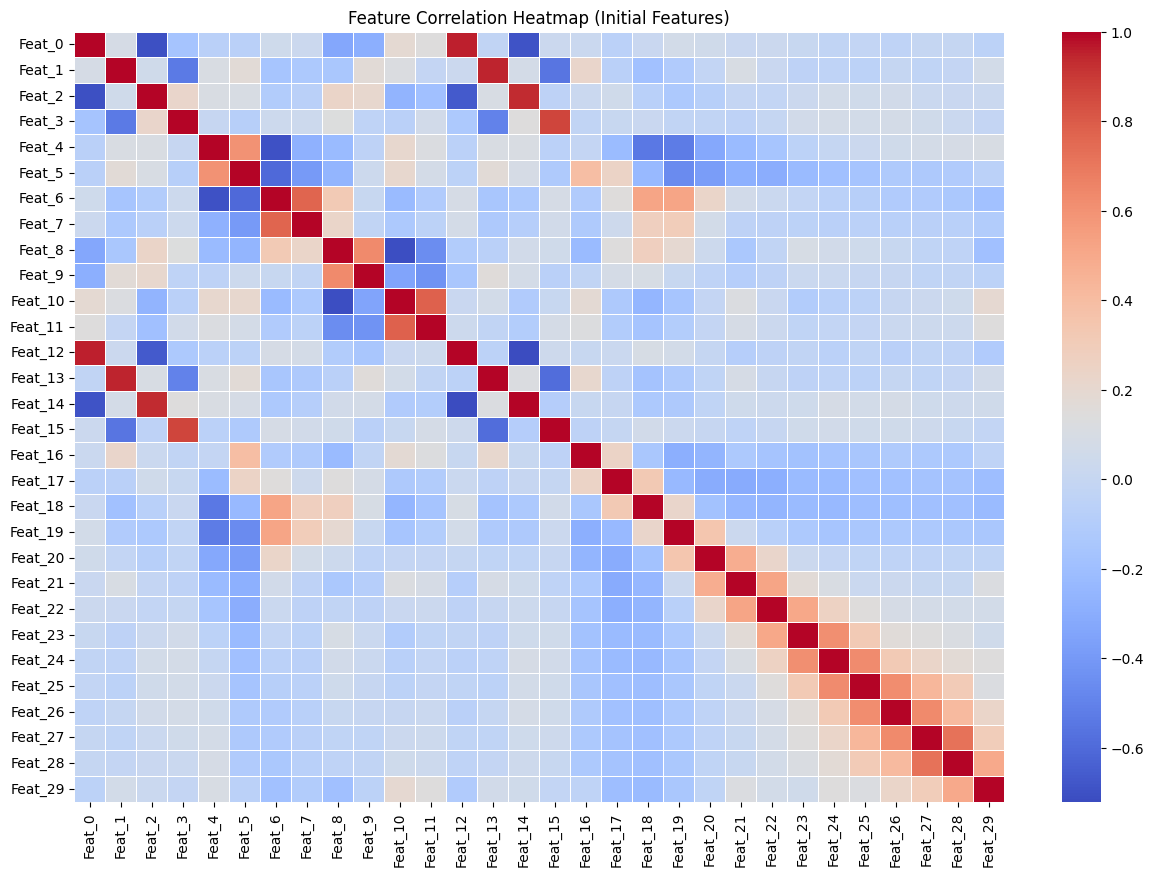

In [17]:
# Create a DataFrame for a subset of features (e.g., the first 30 features)
# These usually represent your Statistical and Hue features
X_sample_df = pd.DataFrame(X_train_scaled[:, :30], 
                           columns=[f"Feat_{i}" for i in range(30)])

plt.figure(figsize=(15, 10))
corr = X_sample_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap (Initial Features)")
plt.show()

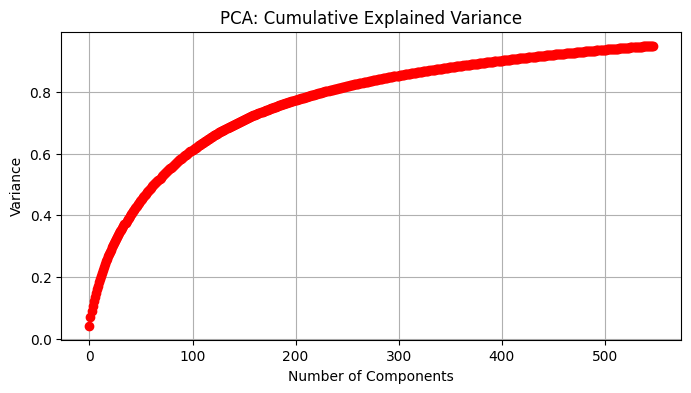

In [13]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='red', marker='o')
plt.title("PCA: Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance")
plt.grid(True)
plt.show()


--- RandomForest Report ---
               precision    recall  f1-score   support

         Cat       0.71      0.76      0.73      2191
         Dog       0.77      0.71      0.74      2400

    accuracy                           0.74      4591
   macro avg       0.74      0.74      0.74      4591
weighted avg       0.74      0.74      0.74      4591

Accuracy score : 0.736005227619255


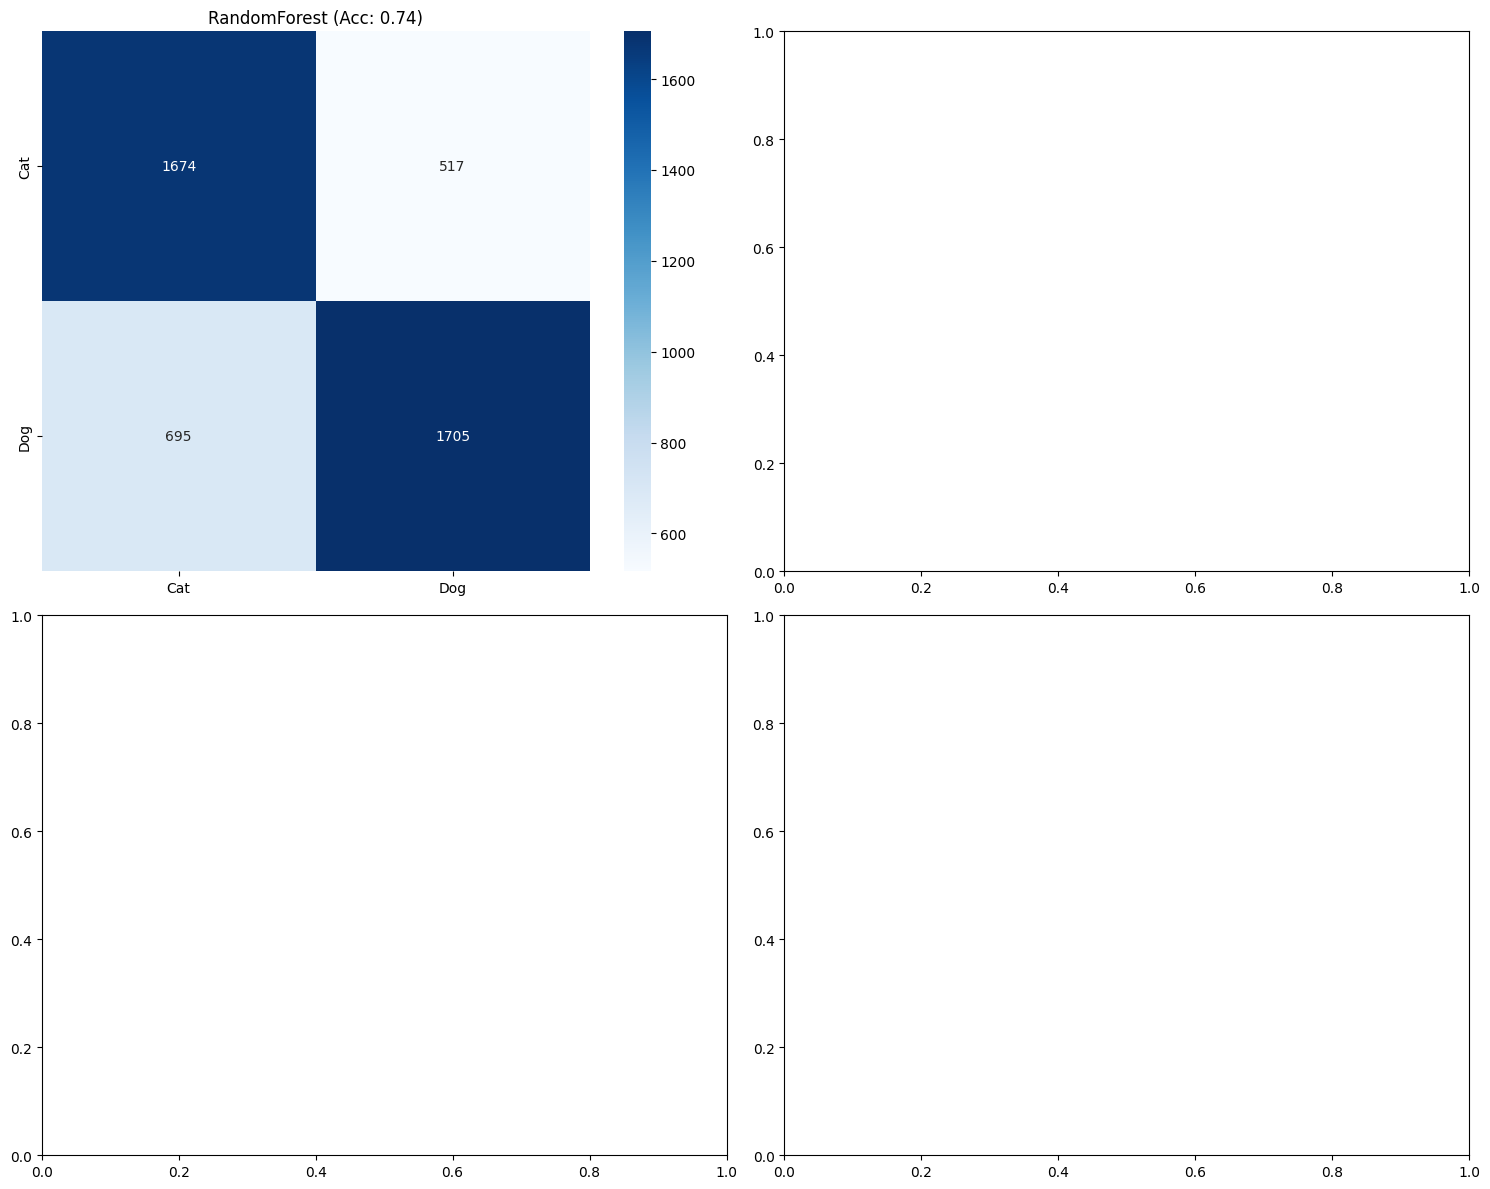

In [15]:
models = {
    # "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    # "SVM": SVC(kernel='rbf', C=10, probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10),
    # "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05)
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    # Train
    model.fit(X_train_pca, y_train_res)
    y_pred = model.predict(X_test_pca)
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f"{name} (Acc: {accuracy_score(y_test, y_pred):.2f})")
    
    # 2. Classification Report
    print(f"\n--- {name} Report ---\n", classification_report(y_test, y_pred, target_names=le.classes_))
    print(f"Accuracy score : {accuracy_score(y_test, y_pred)}")

plt.tight_layout()
plt.show()

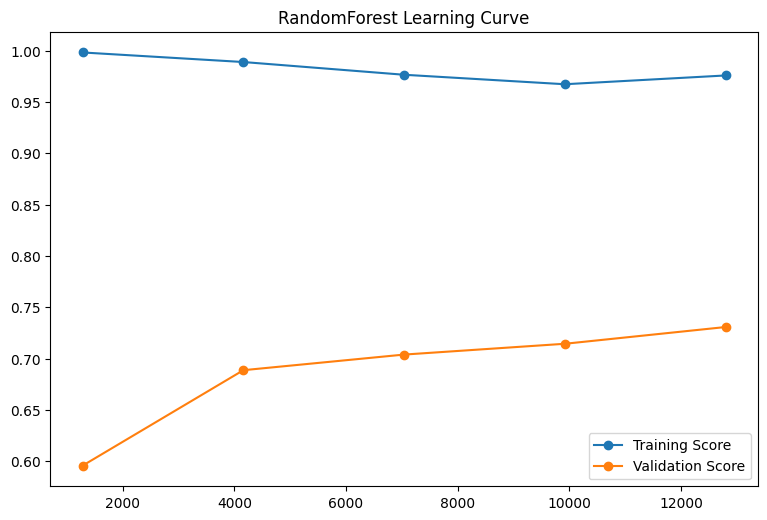

In [16]:
def plot_learning_curves(models, X, y):
    plt.figure(figsize=(15, 10))
    for i, (name, model) in enumerate(models.items()):
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=3, scoring='accuracy', n_jobs=-1, 
            train_sizes=np.linspace(0.1, 1.0, 5)
        )
        
        plt.subplot(2, 2, i+1)
        plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
        plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Validation Score")
        plt.title(f"{name} Learning Curve")
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(models, X_train_pca, y_train_res)

In [ ]:
# # If testing data is present

# def predict_and_visualize(test_folder_path, model, scaler, pca, imputer, le, grid_size=(4, 4)):
#     """
#     Predicts classes for images in a folder and plots them in a grid.
#     """
#     image_files = [f for f in os.listdir(test_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
#     # Select a subset of images for the grid
#     num_images = min(len(image_files), grid_size[0] * grid_size[1])
#     selected_files = image_files[:num_images]
    
#     plt.figure(figsize=(16, 16))
    
#     for i, filename in enumerate(selected_files):
#         img_path = os.path.join(test_folder_path, filename)
#         img_original = cv2.imread(img_path)
        
#         if img_original is None: continue
            
#         # 1. Feature Extraction (Must match training logic exactly)
#         feats = extract_all_features_robust(img_original)
        
#         if feats is not None:
#             # 2. Preprocessing Pipeline
#             # Reshape for a single sample (1, -1)
#             feats_reshaped = feats.reshape(1, -1)
            
#             # Use the SAME imputer, scaler, and pca from training
#             feats_imputed = imputer.transform(feats_reshaped)
#             feats_scaled = scaler.transform(feats_imputed)
#             feats_pca = pca.transform(feats_scaled)
            
#             # 3. Prediction
#             # Note: If your model was trained on PCA features, use feats_pca. 
#             # If trained on scaled features (like your RF might be), use feats_scaled.
#             prediction_idx = model.predict(feats_pca)[0]
#             prediction_label = le.inverse_transform([prediction_idx])[0]
            
#             # Get confidence score if available
#             try:
#                 probs = model.predict_proba(feats_pca)[0]
#                 conf = np.max(probs) * 100
#                 title_text = f"Pred: {prediction_label}\n({conf:.1f}%)"
#             except:
#                 title_text = f"Pred: {prediction_label}"
            
#             # 4. Plotting
#             plt.subplot(grid_size[0], grid_size[1], i + 1)
#             plt.imshow(cv2.cvtColor(cv2.resize(img_original, (128, 128)), cv2.COLOR_BGR2RGB))
#             plt.title(title_text, color='green' if "Tomato" in prediction_label else 'blue')
#             plt.axis('off')
            
#     plt.tight_layout()
#     plt.show()

# # --- HOW TO RUN ---
# # Replace 'test_data_folder' with your actual path to unseen images
# # predict_and_visualize('path/to/your/unseen_test_folder', 
# #                       model=best_model, 
# #                       scaler=scaler, 
# #                       pca=pca, 
# #                       imputer=imputer, 
# #                       le=le)